# Welcome to Colab!

In [ ]:
!pip install tensorflow

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [6]:
import zipfile

with zipfile.ZipFile('Data.zip', 'r') as zip_ref:
    zip_ref.extractall('Data')


In [6]:
DATASET_DIR = 'Data/Data'

IMG_HEIGHT= 224
IMG_WIDTH=224
BATCH_SIZE=32
SEED=42


In [14]:
import os

os.listdir('Data/Data')

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [9]:
train_dataset= tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    image_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED

)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [10]:
validation_dataset= tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    image_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED

)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [11]:
class_names=train_dataset.class_names
num_classes=len(class_names)
num_classes


6

In [13]:
# Base Model (CNN2D)

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Convolution layer: 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Flattening
model.add(tf.keras.layers.Flatten())

# FCL
model.add(tf.keras.layers.Dense(128, activation="relu"))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
EPOCHS=10

history=model.fit(train_dataset,validation_data=validation_dataset,epochs=EPOCHS)


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.2571 - loss: 2.2411 - val_accuracy: 0.2034 - val_loss: 1.7378
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.3475 - loss: 1.5715 - val_accuracy: 0.4463 - val_loss: 1.4612
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 220s 4s/step - accuracy: 0.4901 - loss: 1.3725 - val_accuracy: 0.5198 - val_loss: 1.3057
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.6144 - loss: 1.1241 - val_accuracy: 0.5650 - val_loss: 1.2669
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 48098s 2186s/step - accuracy: 0.7006 - loss: 0.8233 - val_accuracy: 0.6102 - val_loss: 1.2700
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7698 - loss: 0.6609 - val_accuracy: 0.6102 - val_loss: 1.1621
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 907ms/step - accuracy: 0.8814 - loss: 0.3375 - val_accuracy: 0.5876 - val_loss: 1.6083
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 951ms/step - accuracy: 0.9350 - loss: 0.2036 - val_accuracy: 0.531

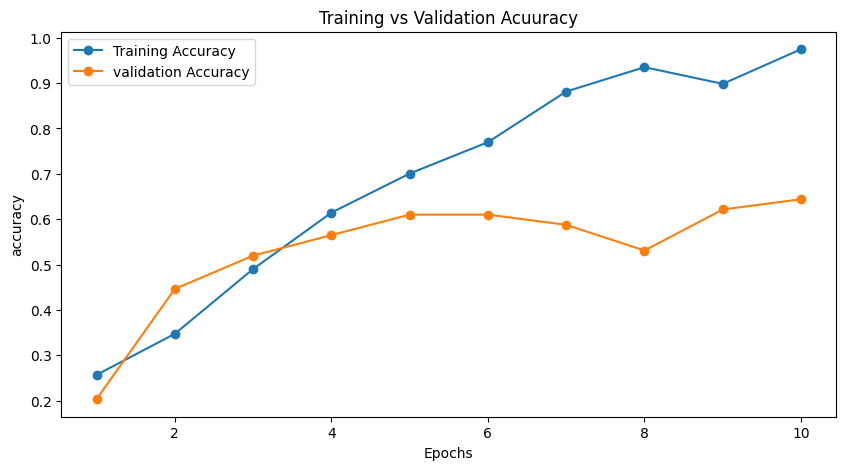

In [17]:
train_accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']
epochs=range(1,EPOCHS+1)
plt.figure(figsize=(10,5))
plt.plot(epochs,train_accuracy,label='Training Accuracy',marker='o')
plt.plot(epochs,val_accuracy,label='validation Accuracy',marker='o')
plt.title("Training vs Validation Acuuracy")
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [18]:
EPOCHS=20

history=model.fit(train_dataset,validation_data=validation_dataset,epochs=EPOCHS)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9901 - loss: 0.0611 - val_accuracy: 0.6667 - val_loss: 1.9536
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4035s 183s/step - accuracy: 0.9887 - loss: 0.0503 - val_accuracy: 0.6667 - val_loss: 1.6843
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 33938s 1543s/step - accuracy: 0.9929 - loss: 0.0444 - val_accuracy: 0.6328 - val_loss: 1.9299
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9958 - loss: 0.0495 - val_accuracy: 0.7062 - val_loss: 1.5422
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9958 - loss: 0.0293 - val_accuracy: 0.6497 - val_loss: 1.7554
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9972 - loss: 0.0239 - val_accuracy: 0.6949 - val_loss: 1.6722
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9944 - loss: 0.0432 - val_accuracy: 0.6554 - val_loss: 1.6030
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9929 - loss: 0.0226 - val_accuracy: 0.6384 -

In [19]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(monitor="val_loss",patience=3)



In [20]:
from tensorflow.keras.callbacks import LearningRateScheduler
def scheduler(epoch,lr):
  if epoch >5:
     return lr*0.1
  return lr

  lr_schedule = LearningRateScheduler(scheduler)

In [21]:



model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255,input_shape=(IMG_HEIGHT,IMG_WIDTH,3)))

model.add(tf.keras.layers.Conv2D(32,(3,3),activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

model.add(tf.keras.layers.Conv2D(64,(3,3),activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.5))


model.add(tf.keras.layers.Conv2D(128,(3,3),activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(128,activation="relu"))


model.add(tf.keras.layers.Dense(num_classes,activation="softmax"))

In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
EPOCHS=10

history=model.fit(train_dataset,validation_data=validation_dataset,epochs=EPOCHS)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.3150 - loss: 14.6085 - val_accuracy: 0.2203 - val_loss: 11.9491
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.4887 - loss: 2.2716 - val_accuracy: 0.1073 - val_loss: 36.2860
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.6003 - loss: 1.3692 - val_accuracy: 0.1073 - val_loss: 40.9862
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.6935 - loss: 0.9302 - val_accuracy: 0.1073 - val_loss: 32.8102
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.7641 - loss: 0.7307 - val_accuracy: 0.1469 - val_loss: 23.0761
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.8178 - loss: 0.5217 - val_accuracy: 0.1808 - val_loss: 24.9444
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.7924 - loss: 0.5888 - val_accuracy: 0.2768 - val_loss: 16.4055
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.8489 - loss: 0.4467 - val_accuracy: 0.2486 - v

In [24]:
# chat gpt recommendation code
# Use a simpler CNN + data augmentation + smaller dense layer.



import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(500).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.2331 - loss: 1.7539 - val_accuracy: 0.2881 - val_loss: 1.7165 - learning_rate: 5.0000e-04
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.2740 - loss: 1.7117 - val_accuracy: 0.4068 - val_loss: 1.6549 - learning_rate: 5.0000e-04
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.3178 - loss: 1.6492 - val_accuracy: 0.3277 - val_loss: 1.6651 - learning_rate: 5.0000e-04
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.3418 - loss: 1.6387 - val_accuracy: 0.2542 - val_loss: 1.6979 - learning_rate: 5.0000e-04
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.3489 - loss: 1.5923 - val_accuracy: 0.3277 - val_loss: 1.6745 - learning_rate: 1.5000e-04
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.3545 - loss: 1.6006 - val_accuracy: 0.2881 - val_loss: 1.7173 - learning_rate: 1.5000e-04
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.3785 - loss:

In [26]:
base_model=tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
base_model.trainable=False
model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(224,224,3)))


In [4]:
import tensorflow as tf
from tensorflow.keras.layers import (
    RandomFlip, RandomRotation, RandomZoom,
    Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    Flatten, Dropout, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras.layers import (
    RandomFlip, RandomRotation, RandomZoom,
    Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    Flatten, Dropout, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [44]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.15),
    RandomZoom(0.15),
    # Optional: add RandomContrast(0.2) if colors vary a lot
])

In [45]:
print(data_augmentation)

<Sequential name=sequential_14, built=False>


In [46]:
base_model=tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [47]:
base_model.trainable=False
model =tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_augmentation)
model.add(tf.keras.layers.Rescaling(1.0/255))


model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.Dense(num_classes,activation='softmax'))

In [48]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_14 (Sequential)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_6 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [51]:
history=model.fit(train_dataset,
                  validation_data=validation_dataset,epochs=10)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 31s 990ms/step - accuracy: 0.4703 - loss: 1.4015 - val_accuracy: 0.4802 - val_loss: 1.3170
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 910ms/step - accuracy: 0.7076 - loss: 0.8361 - val_accuracy: 0.6158 - val_loss: 1.0398
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 40s 840ms/step - accuracy: 0.7429 - loss: 0.7144 - val_accuracy: 0.6215 - val_loss: 1.0591
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 833ms/step - accuracy: 0.7768 - loss: 0.6345 - val_accuracy: 0.5537 - val_loss: 1.1301
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 869ms/step - accuracy: 0.8220 - loss: 0.5439 - val_accuracy: 0.6667 - val_loss: 0.8703
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 873ms/step - accuracy: 0.8178 - loss: 0.5296 - val_accuracy: 0.5593 - val_loss: 1.2919
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 835ms/step - accuracy: 0.8460 - loss: 0.4401 - val_accuracy: 0.5876 - val_loss: 1.1394
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 867ms/step - accuracy: 0.8489 - loss: 0.4195 - val_accu

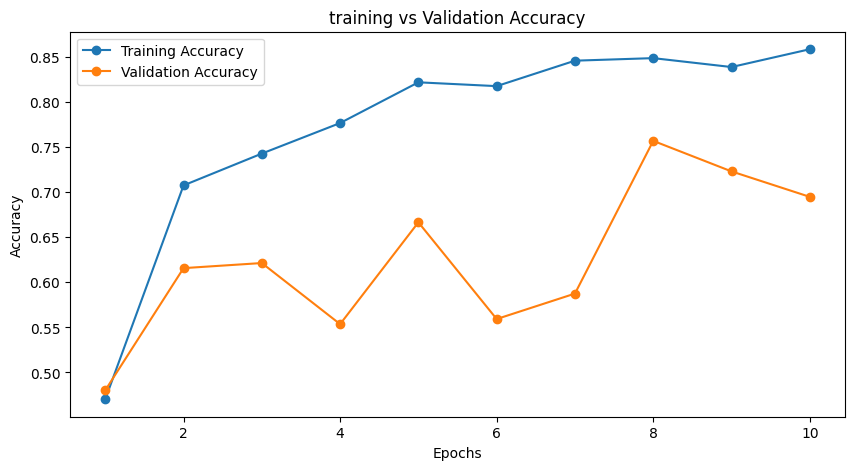

In [54]:
train_accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']
epochs=range(1,11)

plt.figure(figsize=(10,5))
plt.plot(epochs,train_accuracy,label='Training Accuracy',marker='o')
plt.plot(epochs,val_accuracy,label='Validation Accuracy',marker='o')
plt.title('training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [56]:
model.save("solar_panel_classification.keras")

# model.save('solar panel classification')

In [2]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0,preprocess_input


In [7]:
train_dataset=tf.keras.utils.image_dataset_from_directory(DATASET_DIR,
validation_split=0.2,
subset="training",
image_size=(IMG_HEIGHT,IMG_WIDTH),
batch_size=BATCH_SIZE,
seed=SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [8]:
validation_dataset=tf.keras.utils.image_dataset_from_directory(DATASET_DIR,validation_split=0.2,
                                                               subset="validation",
                                                               image_size=(IMG_HEIGHT,IMG_WIDTH),
                                                               batch_size=BATCH_SIZE,
                                                               seed=SEED

)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [9]:
class_names=train_dataset.class_names

In [10]:
num_classes=len(class_names)

In [11]:
num_classes

6

In [15]:
class_counts={}
total_images=0

for class_name in class_names:
     class_path=os.path.join(DATASET_DIR,class_name)
     count=len(os.listdir(class_path))
     class_counts[class_name]=count
     total_images+=count

In [16]:
class_weights={}

for index,class_name in enumerate(class_names):
     class_weights[index]=total_images/(num_classes *class_counts[class_name])
print("class Weights",class_weights)

class Weights {0: 0.7530224525043178, 1: 0.7491408934707904, 2: 0.7649122807017544, 3: 1.4110032362459546, 4: 2.106280193236715, 5: 1.1815718157181572}


In [17]:
data_augmentation = tf.keras.Sequential()
data_augmentation.add(tf.keras.layers.RandomFlip("horizontal"))
data_augmentation.add(tf.keras.layers.RandomRotation(0.1))
data_augmentation.add(tf.keras.layers.RandomZoom(0.1))

In [18]:
train_images = []
train_labels = []

In [19]:
for images, labels in train_dataset:
  images = preprocess_input(images)
  train_images.append(images)
  train_labels.append(labels)

In [20]:
train_images = tf.concat(train_images, axis=0)
train_labels = tf.concat(train_labels, axis=0)

In [21]:
validation_images = []
validation_labels = []

In [22]:
for images, labels in validation_dataset:
  images = preprocess_input(images)
  validation_images.append(images)
  validation_labels.append(labels)

In [23]:
validation_images = tf.concat(validation_images, axis=0)
validation_labels = tf.concat(validation_labels, axis=0)

In [24]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape = (224,224,3),
    include_top = False,
    weights="imagenet"
)

In [25]:
base_model.trainable = False

In [26]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_augmentation)

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [29]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 15
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.5466 - loss: 1.2145 - val_accuracy: 0.6441 - val_loss: 0.9364
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.7472 - loss: 0.7242 - val_accuracy: 0.6949 - val_loss: 0.8106
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.7895 - loss: 0.5747 - val_accuracy: 0.7232 - val_loss: 0.7278
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.8404 - loss: 0.4762 - val_accuracy: 0.7401 - val_loss: 0.7312
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.8376 - loss: 0.4707 - val_accuracy: 0.7514 - val_loss: 0.6738
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.8799 - loss: 0.3881 - val_accuracy: 0.7684 - val_loss: 0.6622
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.9124 - loss: 0.3055 - val_accuracy: 0.7684 - val_loss: 0.6572
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.8983 - loss: 0.2947 - val_accuracy: 0.7684 - val_loss:

In [30]:
!pip install keras-tuner

In [36]:
 # Run if not installed

import keras_tuner as kt
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Reuse your train_dataset and validation_dataset (with preprocess_input already applied)
# Make sure they are defined as in your original code

def build_model(hp):
    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(hp.Float("rotation_factor", min_value=0.05, max_value=0.3, step=0.05)),
        RandomZoom(hp.Float("zoom_factor", min_value=0.05, max_value=0.3, step=0.05)),
        base_model,
        GlobalAveragePooling2D(),
        Dropout(hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)),
        Dense(
            hp.Int("dense_units", min_value=64, max_value=512, step=64),
            activation='relu'
        ),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=3,
    executions_per_trial=1,
    directory='kt_dir',
    project_name='efficientnet_tune',
    overwrite=True
)



# Optional: Early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)


tuner.search(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# # Run the search
# tuner.search(
#     train_dataset,
#     validation_data=validation_dataset,
#     epochs=10,
#     callbacks=[early_stopping],
#     class_weight=class_weights  # Handles imbalance
# )

# Results
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hps.values)

best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate on validation






val_loss, val_acc = best_model.evaluate(validation_dataset)
print(f"Best validation accuracy: {val_acc:.4f}")

Trial 3 Complete [00h 06m 50s]
val_accuracy: 0.7344632744789124

Best val_accuracy So Far: 0.7966101765632629
Total elapsed time: 00h 28m 18s
Best hyperparameters:
{'rotation_factor': 0.05, 'zoom_factor': 0.25, 'dropout_rate': 0.0, 'dense_units': 64, 'learning_rate': 0.002240080343891231}
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 902ms/step - accuracy: 0.7966 - loss: 0.6468
Best validation accuracy: 0.7966


In [40]:
best_model.save('Solar Panel Classification/trained_effnet_finetune.keras')

In [42]:
best_model.save("trained_effnet_finetune.keras")

In [43]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\Harsh
['.anaconda', '.bash_history', '.cache', '.conda', '.condarc', '.continuum', '.csv', '.gitconfig', '.idea', '.ipynb_checkpoints', '.ipynb_checkpoints.zip', '.ipython', '.jupyter', '.keras', '.matplotlib', '.ms-ad', '.ollama', '.python_history', '.ssh', '.viminfo', '.virtual_documents', '.vscode', '.vscode-shared', '00-Decision-Trees.ipynb', '00-KNN-Classification-checkpoint (1).ipynb', '50_Startups.csv', 'anaconda3', 'anaconda_projects', 'app.py', 'AppData', 'Application Data', 'breast_cancer.csv', 'build', 'cement_slump.csv', 'clustering.ipynb', 'Contacts', 'Cookies', 'data', 'Data.zip', 'DataScienceEcosystem.ipynb', 'Datasets', 'Desktop', 'Documents', 'Downloads', 'DSA bit.ipynb', 'DSA1.ipynb', 'Dynamic programming ,trie.ipynb', 'ensemble..ipynb', 'Favorites', 'feature engineering.ipynb', 'HPOdeployment.ipynb', 'huggingface_crash_course.ipynb', 'imp_python_programs_baisc_good_reference[1].ipynb', 'kt_dir', 'Links', 'Local Settings', 'log', 'machine learning 44 hours', 